# 09 Bulk vs Single-Cell Egress and Retention Comparison

Compare egress and retention/residency genes across the Von Hoesslin bulk DP RNA-seq and the Kallies single-cell dataset in one plot.

Interpretation mapping used here:

- Bulk `DP_nr_d0` is treated as the closest match to single-cell `LPL_memory` / SI LPL.
- Bulk `DP_wt_d2` and `DP_ova_d2` are treated as imperfect d2 comparators to single-cell `IEL_memory` / SI IEL.

Because bulk RNA-seq and scRNA-seq expression values are not on the same scale, the combined expression plot uses gene-wise z-scores within each dataset.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import sys
sys.path.append("/home/dk5299/Projects_31926/RNA-seq/Kallies_Sci_Immuno_2025")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.paths import RESULTS_DIR

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300


/tmp/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-rlnsw4on because there was an issue with the default path (/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Genes and Inputs


In [2]:
egress_genes = ["Ccr7", "S1pr1", "Klf2"]
retention_genes = ["Cd69", "Itgae", "Ccr9", "Cxcr6"]
comparison_genes = egress_genes + retention_genes

gene_program = {gene: "egress" for gene in egress_genes}
gene_program.update({gene: "retention" for gene in retention_genes})

bulk_dir = RESULTS_DIR / "07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics"
sc_dir = RESULTS_DIR / "08_sc_dp_like_marker_dynamics"
output_dir = RESULTS_DIR / "09_bulk_sc_egress_retention_comparison"
output_dir.mkdir(parents=True, exist_ok=True)

bulk_expr_file = bulk_dir / "07_dp_egress_residency_custom_expression_summary.tsv"
bulk_de_file = bulk_dir / "07_dp_egress_residency_custom_deseq_stats.tsv"
sc_expr_file = sc_dir / "08_sc_marker_expression_by_condition.tsv"

comparison_genes


['Ccr7', 'S1pr1', 'Klf2', 'Cd69', 'Itgae', 'Ccr9', 'Cxcr6']

## Load Summary Tables


In [3]:
bulk_expr = pd.read_csv(bulk_expr_file, sep="	")
bulk_de = pd.read_csv(bulk_de_file, sep="	")
sc_expr = pd.read_csv(sc_expr_file, sep="	")

bulk_expr = bulk_expr[bulk_expr["gene"].isin(comparison_genes)].copy()
bulk_de = bulk_de[bulk_de["gene"].isin(comparison_genes)].copy()
sc_expr = sc_expr[sc_expr["gene"].isin(comparison_genes)].copy()

bulk_expr["gene"] = pd.Categorical(bulk_expr["gene"], categories=comparison_genes, ordered=True)
sc_expr["gene"] = pd.Categorical(sc_expr["gene"], categories=comparison_genes, ordered=True)

bulk_expr.head(), sc_expr.head()


(    gene  condition  mean_log2_cpm  median_log2_cpm  sd_log2_cpm  n_samples  \
 0   Ccr7   DP_nr_d0       1.127877         1.097681     0.624909          3   
 1   Ccr7   DP_wt_d2       5.111593         4.594650     1.077628          5   
 2   Ccr7  DP_ova_d2       5.668147         5.743432     0.537870          4   
 3  S1pr1   DP_nr_d0       1.766661         2.232949     1.585794          3   
 4  S1pr1   DP_wt_d2       3.486235         3.335483     0.586128          5   
 
    pct_detected  
 0     66.666667  
 1    100.000000  
 2    100.000000  
 3     66.666667  
 4    100.000000  ,
    gene    condition  mean_log1p  median_log1p  pct_detected  n_cells
 0  Ccr7   IEL_memory    0.019397      0.000000      1.851483     5023
 1  Ccr7   LPL_memory    0.016153      0.000000      1.882796     4249
 2  Ccr7  rechallenge    0.040783      0.000000      3.177428     3934
 3  Ccr9   IEL_memory    1.147429      1.196627     66.832570     5023
 4  Ccr9   LPL_memory    0.924426      0.878490 

## Build Matched Expression Matrix

For the expression heatmap, values are z-scored by gene within each dataset before combining. This preserves within-dataset direction without pretending bulk log2CPM and sc log-normalized counts are directly comparable.


In [10]:
bulk_expr_matrix = (
    bulk_expr.pivot(index="gene", columns="condition", values="mean_log2_cpm")
    .reindex(index=comparison_genes, columns=["DP_nr_d0", "DP_wt_d2", "DP_ova_d2"])
)

sc_expr_matrix = (
    sc_expr.pivot(index="gene", columns="condition", values="mean_log1p")
    .reindex(index=comparison_genes, columns=["LPL_memory", "IEL_memory", "rechallenge"])
)

bulk_z = bulk_expr_matrix.sub(bulk_expr_matrix.mean(axis=1), axis=0).div(bulk_expr_matrix.std(axis=1).replace(0, np.nan), axis=0)
sc_z = sc_expr_matrix.sub(sc_expr_matrix.mean(axis=1), axis=0).div(sc_expr_matrix.std(axis=1).replace(0, np.nan), axis=0)

combined_expr_z = pd.concat(
    [
        bulk_z.rename(columns={
            "DP_nr_d0": "bulk d0\nDP nr\n(LPL-like)",
            "DP_wt_d2": "bulk d2\nDP wt\n(IEL-like)",
            "DP_ova_d2": "bulk d2\nDP ova\n(IEL-like)",
        }),
        sc_z.rename(columns={
            "LPL_memory": "sc\nSI LPL",
            "IEL_memory": "sc\nSI IEL",
            "rechallenge": "sc\nrechallenge",
        }),
    ],
    axis=1,
)

combined_expr_z.insert(0, "program", [gene_program[gene] for gene in combined_expr_z.index])
expr_z_file = output_dir / "09_bulk_sc_egress_retention_expression_z.tsv"
combined_expr_z.to_csv(expr_z_file, sep="	")
print("Saved:", expr_z_file)
combined_expr_z


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/09_bulk_sc_egress_retention_comparison/09_bulk_sc_egress_retention_expression_z.tsv


condition,program,bulk d0\nDP nr\n(LPL-like),bulk d2\nDP wt\n(IEL-like),bulk d2\nDP ova\n(IEL-like),sc\nSI LPL,sc\nSI IEL,sc\nrechallenge
gene,,,,,,,
Ccr7,egress,-1.147387,0.461319,0.686067,-0.694325,-0.451858,1.146184
S1pr1,egress,-1.145155,0.444263,0.700892,1.152831,-0.519526,-0.633304
Klf2,egress,-1.084399,0.198603,0.885797,-0.619539,-0.534107,1.153647
Cd69,retention,-0.458377,1.147022,-0.688644,-1.053562,0.117508,0.936055
Itgae,retention,1.149867,-0.483528,-0.666338,0.159932,0.910396,-1.070328
Ccr9,retention,1.150529,-0.490343,-0.660187,-0.065995,1.031363,-0.965368
Cxcr6,retention,0.921656,0.141594,-1.063250,0.975086,0.048092,-1.023178


## Build Direction/Delta Matrix

Bulk direction uses the existing DESeq2 log2FC values for d2 vs d0. Single-cell direction is the simple mean-expression difference, `IEL_memory - LPL_memory`, on log-normalized expression.


In [11]:
bulk_lfc = (
    bulk_de.pivot(index="gene", columns="contrast", values="log2FoldChange")
    .reindex(index=comparison_genes, columns=["DP_d2_wt_vs_d0_nr", "DP_d2_ova_vs_d0_nr"])
    .rename(columns={
        "DP_d2_wt_vs_d0_nr": "bulk d2 wt\nvs d0",
        "DP_d2_ova_vs_d0_nr": "bulk d2 ova\nvs d0",
    })
)

bulk_padj = (
    bulk_de.pivot(index="gene", columns="contrast", values="padj")
    .reindex(index=comparison_genes, columns=["DP_d2_wt_vs_d0_nr", "DP_d2_ova_vs_d0_nr"])
    .rename(columns={
        "DP_d2_wt_vs_d0_nr": "bulk d2 wt\nvs d0",
        "DP_d2_ova_vs_d0_nr": "bulk d2 ova\nvs d0",
    })
)

sc_delta = pd.DataFrame({
    "sc IEL\nminus LPL": sc_expr_matrix["IEL_memory"] - sc_expr_matrix["LPL_memory"],
    "sc rechallenge\nminus LPL": sc_expr_matrix["rechallenge"] - sc_expr_matrix["LPL_memory"],
    "sc rechallenge\nminus IEL": sc_expr_matrix["rechallenge"] - sc_expr_matrix["IEL_memory"],
})
combined_delta = pd.concat([bulk_lfc, sc_delta], axis=1)
combined_delta.insert(0, "program", [gene_program[gene] for gene in combined_delta.index])

delta_file = output_dir / "09_bulk_sc_egress_retention_delta.tsv"
combined_delta.to_csv(delta_file, sep="	")
print("Saved:", delta_file)
combined_delta


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/09_bulk_sc_egress_retention_comparison/09_bulk_sc_egress_retention_delta.tsv


,program,bulk d2 wt\nvs d0,bulk d2 ova\nvs d0,sc IEL\nminus LPL,sc rechallenge\nminus LPL,sc rechallenge\nminus IEL
gene,,,,,,
Ccr7,egress,5.271013,5.618728,0.003245,0.024630,0.021385
S1pr1,egress,1.023921,1.386001,-0.107119,-0.114407,-0.007288
Klf2,egress,0.739503,1.141424,0.021021,0.436297,0.415276
Cd69,retention,0.650997,0.381729,0.227818,0.387057,0.159239
Itgae,retention,-0.231721,-0.222859,0.177678,-0.291273,-0.468950
Ccr9,retention,-0.122903,-0.061046,0.223003,-0.182769,-0.405772
Cxcr6,retention,-0.069071,-0.563307,-0.252108,-0.543454,-0.291346


## Combined Plot


/tmp/ipykernel_4180792/1485778040.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/09_bulk_sc_egress_retention_comparison/09_bulk_sc_egress_retention_combined_heatmap.png
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/09_bulk_sc_egress_retention_comparison/09_bulk_sc_egress_retention_combined_heatmap.pdf


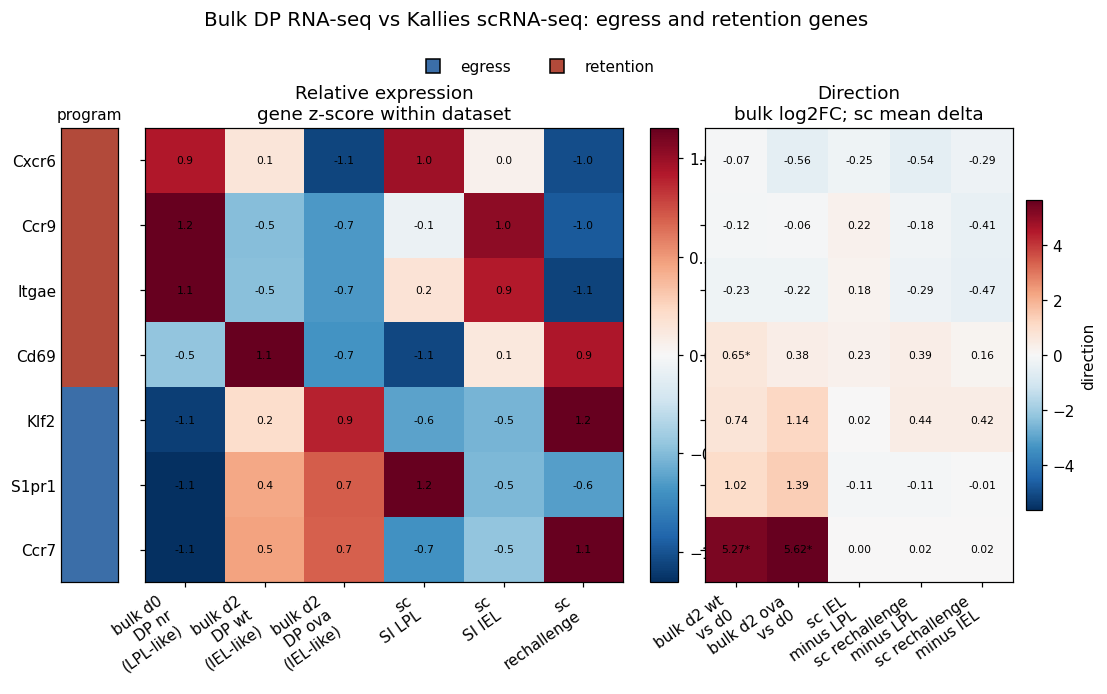

In [12]:
plot_genes = list(reversed(comparison_genes))
program_colors = {"egress": "#3b6ea8", "retention": "#b24a3a"}

expr_plot = combined_expr_z.drop(columns="program").reindex(plot_genes)
delta_plot = combined_delta.drop(columns="program").reindex(plot_genes)
padj_plot = bulk_padj.reindex(plot_genes)

fig = plt.figure(figsize=(11.5, max(4.8, 0.48 * len(plot_genes) + 2.0)))
gs = fig.add_gridspec(1, 4, width_ratios=[0.16, 1.35, 0.08, 0.95], wspace=0.12)

ax_program = fig.add_subplot(gs[0, 0])
program_values = np.array([[0 if gene_program[gene] == "egress" else 1] for gene in plot_genes])
ax_program.imshow(program_values, aspect="auto", cmap=plt.matplotlib.colors.ListedColormap([program_colors["egress"], program_colors["retention"]]))
ax_program.set_xticks([])
ax_program.set_yticks(range(len(plot_genes)))
ax_program.set_yticklabels(plot_genes)
ax_program.tick_params(axis="y", length=0)
ax_program.set_title("program", fontsize=10)

ax_expr = fig.add_subplot(gs[0, 1])
expr_max = np.nanmax(np.abs(expr_plot.values))
im1 = ax_expr.imshow(expr_plot.values, cmap="RdBu_r", vmin=-expr_max, vmax=expr_max, aspect="auto")
ax_expr.set_xticks(range(expr_plot.shape[1]))
ax_expr.set_xticklabels(expr_plot.columns, rotation=35, ha="right")
ax_expr.set_yticks(range(len(plot_genes)))
ax_expr.set_yticklabels([])
ax_expr.set_title("Relative expression\ngene z-score within dataset")
for i in range(expr_plot.shape[0]):
    for j in range(expr_plot.shape[1]):
        value = expr_plot.iloc[i, j]
        if pd.notna(value):
            ax_expr.text(j, i, f"{value:.1f}", ha="center", va="center", fontsize=7)

cax1 = fig.add_subplot(gs[0, 2])
cbar1 = fig.colorbar(im1, cax=cax1)
cbar1.set_label("z")

ax_delta = fig.add_subplot(gs[0, 3])
delta_max = np.nanmax(np.abs(delta_plot.values))
delta_max = max(delta_max, 0.5)
im2 = ax_delta.imshow(delta_plot.values, cmap="RdBu_r", vmin=-delta_max, vmax=delta_max, aspect="auto")
ax_delta.set_xticks(range(delta_plot.shape[1]))
ax_delta.set_xticklabels(delta_plot.columns, rotation=35, ha="right")
ax_delta.set_yticks(range(len(plot_genes)))
ax_delta.set_yticklabels([])
ax_delta.set_title("Direction\nbulk log2FC; sc mean delta")

for i, gene in enumerate(plot_genes):
    for j, col in enumerate(delta_plot.columns):
        value = delta_plot.loc[gene, col]
        if pd.isna(value):
            label = "NA"
        else:
            label = f"{value:.2f}"
            if col in padj_plot.columns:
                padj = padj_plot.loc[gene, col]
                if pd.notna(padj) and padj < 0.05:
                    label += "*"
        ax_delta.text(j, i, label, ha="center", va="center", fontsize=7)

cbar2 = fig.colorbar(im2, ax=ax_delta, fraction=0.046, pad=0.04)
cbar2.set_label("direction")

legend_handles = [
    plt.Line2D([0], [0], marker="s", color="none", markerfacecolor=color, markersize=9, label=label)
    for label, color in program_colors.items()
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)
fig.suptitle("Bulk DP RNA-seq vs Kallies scRNA-seq: egress and retention genes", y=1.08, fontsize=13)
fig.tight_layout()

plot_png = output_dir / "09_bulk_sc_egress_retention_combined_heatmap.png"
plot_pdf = output_dir / "09_bulk_sc_egress_retention_combined_heatmap.pdf"
fig.savefig(plot_png, bbox_inches="tight")
fig.savefig(plot_pdf, bbox_inches="tight")
print("Saved:", plot_png)
print("Saved:", plot_pdf)


## Dot-Plot Style Expression Panel

This version uses dots to show relative expression intensity and sc percent-detected values where available.


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/09_bulk_sc_egress_retention_comparison/09_bulk_sc_egress_retention_expression_dotplot.png
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/09_bulk_sc_egress_retention_comparison/09_bulk_sc_egress_retention_expression_dotplot.pdf


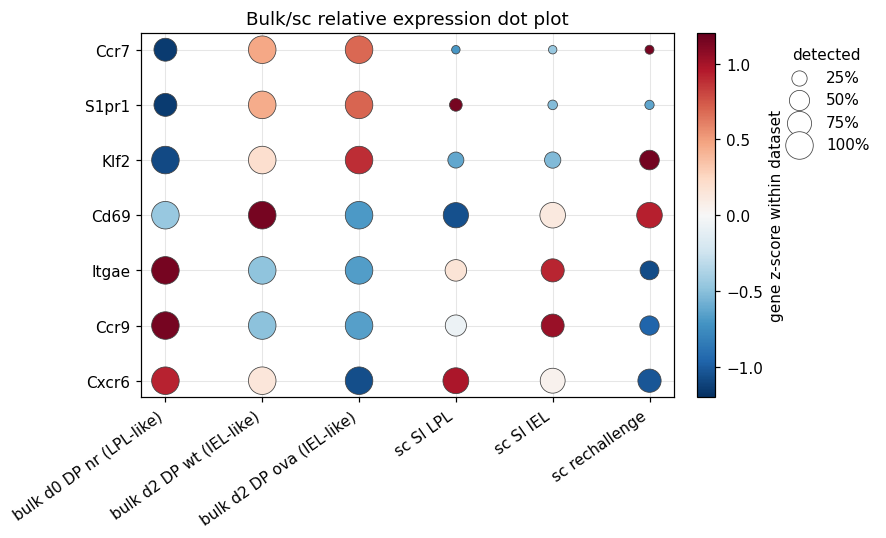

In [13]:
bulk_dot = bulk_expr.copy()
bulk_dot["dataset"] = "bulk"
bulk_dot["display_condition"] = bulk_dot["condition"].map({
    "DP_nr_d0": "bulk d0 DP nr (LPL-like)",
    "DP_wt_d2": "bulk d2 DP wt (IEL-like)",
    "DP_ova_d2": "bulk d2 DP ova (IEL-like)",
})
bulk_dot["mean_value"] = bulk_dot["mean_log2_cpm"]
bulk_dot["pct_detected_plot"] = bulk_dot["pct_detected"]

sc_dot = sc_expr.copy()
sc_dot["dataset"] = "sc"
sc_dot["display_condition"] = sc_dot["condition"].map({
    "LPL_memory": "sc SI LPL",
    "IEL_memory": "sc SI IEL",
    "rechallenge": "sc rechallenge",
})
sc_dot["mean_value"] = sc_dot["mean_log1p"]
sc_dot["pct_detected_plot"] = sc_dot["pct_detected"]

dot_df = pd.concat([
    bulk_dot[["gene", "dataset", "display_condition", "mean_value", "pct_detected_plot"]],
    sc_dot[["gene", "dataset", "display_condition", "mean_value", "pct_detected_plot"]],
], ignore_index=True)

dot_df["expr_z"] = dot_df.groupby(["dataset", "gene"], observed=True)["mean_value"].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0
)

condition_display_order = [
    "bulk d0 DP nr (LPL-like)",
    "bulk d2 DP wt (IEL-like)",
    "bulk d2 DP ova (IEL-like)",
    "sc SI LPL",
    "sc SI IEL",
    "sc rechallenge",
]

dot_df["gene"] = pd.Categorical(dot_df["gene"].astype(str), categories=list(reversed(comparison_genes)), ordered=True)
dot_df["display_condition"] = pd.Categorical(dot_df["display_condition"], categories=condition_display_order, ordered=True)
dot_df = dot_df.sort_values(["gene", "display_condition"])

fig, ax = plt.subplots(figsize=(8.2, max(4.2, 0.5 * len(comparison_genes) + 1.5)))
x = dot_df["display_condition"].cat.codes
y = dot_df["gene"].cat.codes
sizes = 25 + dot_df["pct_detected_plot"].fillna(0) / 100 * 300
scat = ax.scatter(x, y, s=sizes, c=dot_df["expr_z"], cmap="RdBu_r", vmin=-1.2, vmax=1.2, edgecolor="0.25", linewidth=0.5)

ax.set_xticks(range(len(condition_display_order)))
ax.set_xticklabels(condition_display_order, rotation=35, ha="right")
ax.set_yticks(range(len(comparison_genes)))
ax.set_yticklabels(list(reversed(comparison_genes)))
ax.set_title("Bulk/sc relative expression dot plot")
ax.grid(axis="both", color="0.9", linewidth=0.7)
ax.set_axisbelow(True)

cbar = fig.colorbar(scat, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("gene z-score within dataset")

legend_values = [25, 50, 75, 100]
handles = [ax.scatter([], [], s=25 + v / 100 * 300, color="white", edgecolor="0.25", linewidth=0.5) for v in legend_values]
ax.legend(handles, [f"{v}%" for v in legend_values], title="detected", frameon=False, loc="upper left", bbox_to_anchor=(1.18, 1.0))

fig.tight_layout()
dot_png = output_dir / "09_bulk_sc_egress_retention_expression_dotplot.png"
dot_pdf = output_dir / "09_bulk_sc_egress_retention_expression_dotplot.pdf"
fig.savefig(dot_png, bbox_inches="tight")
fig.savefig(dot_pdf, bbox_inches="tight")
print("Saved:", dot_png)
print("Saved:", dot_pdf)
